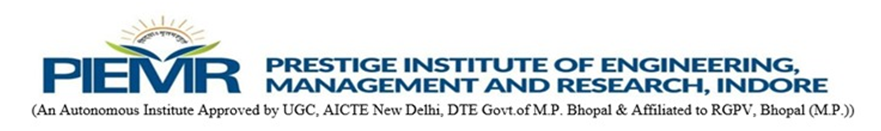

<h2 align="left">Department of AI & Data Science</h2>

<h2 align="left">Data Mining & Warehousing Lab </h2>

<h2 align="left"> Course Instructor: Dr. Rajesh Kumar</h2>


<h2 align="left">Experiment 7</h2>

<h2 align="left">Rule-Based Classification using Weather Dataset</h2>


<h2 align="left"> Objective </h2>

To implement a Rule-Based Classification System using the Weather Dataset and generate simple IF–THEN rules for prediction.

Python Libraries Used

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from sklearn import tree



STEP 1: Load Dataset

Your dataset path:

In [3]:
path = r"C:\Users\rjesh\weather_data.csv"

df = pd.read_csv(path)

print(df.head())



       Location            Date_Time  Temperature_C  Humidity_pct  \
0     San Diego  2024-01-14 21:12:46      10.683001     41.195754   
1     San Diego  2024-05-17 15:22:10       8.734140     58.319107   
2     San Diego  2024-05-11 09:30:59      11.632436     38.820175   
3  Philadelphia  2024-02-26 17:32:39      -8.628976     54.074474   
4   San Antonio  2024-04-29 13:23:51      39.808213     72.899908   

   Precipitation_mm  Wind_Speed_kmh  
0          4.020119        8.233540  
1          9.111623       27.715161  
2          4.607511       28.732951  
3          3.183720       26.367303  
4          9.598282       29.898622  


STEP 2: Explore Dataset

In [4]:
print(df.shape)

print(df.columns)

print(df.info())



(1000000, 6)
Index(['Location', 'Date_Time', 'Temperature_C', 'Humidity_pct',
       'Precipitation_mm', 'Wind_Speed_kmh'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 6 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   Location          1000000 non-null  object 
 1   Date_Time         1000000 non-null  object 
 2   Temperature_C     1000000 non-null  float64
 3   Humidity_pct      1000000 non-null  float64
 4   Precipitation_mm  1000000 non-null  float64
 5   Wind_Speed_kmh    1000000 non-null  float64
dtypes: float64(4), object(2)
memory usage: 45.8+ MB
None


Explanation

Typical weather datasets contain:
| Feature     | Meaning            |
| ----------- | ------------------ |
| outlook     | sunny/rainy/cloudy |
| temperature | hot/mild/cool      |
| humidity    | high/normal        |
| windy       | true/false         |
| play        | yes/no             |


STEP 3: Visualize Dataset

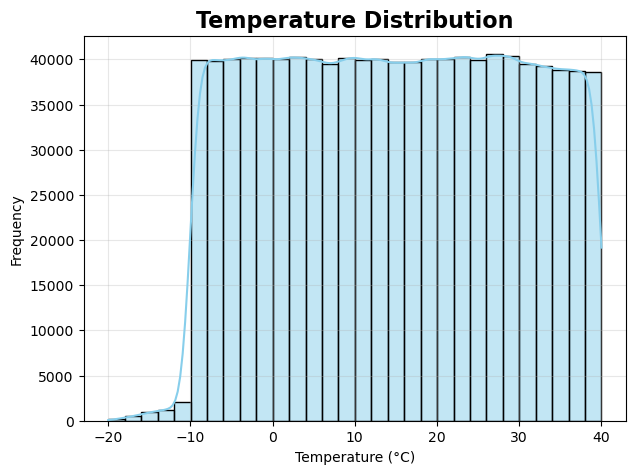

In [5]:
plt.figure(figsize=(7,5))

sns.histplot(
    df['Temperature_C'],
    bins=30,
    kde=True,
    color='skyblue'
)

plt.title(
    "Temperature Distribution",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()



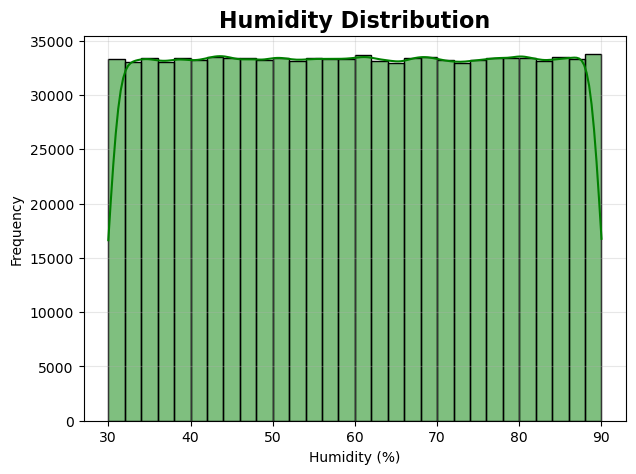

In [6]:
plt.figure(figsize=(7,5))

sns.histplot(
    df['Humidity_pct'],
    bins=30,
    kde=True,
    color='green'
)

plt.title(
    "Humidity Distribution",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Humidity (%)")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()



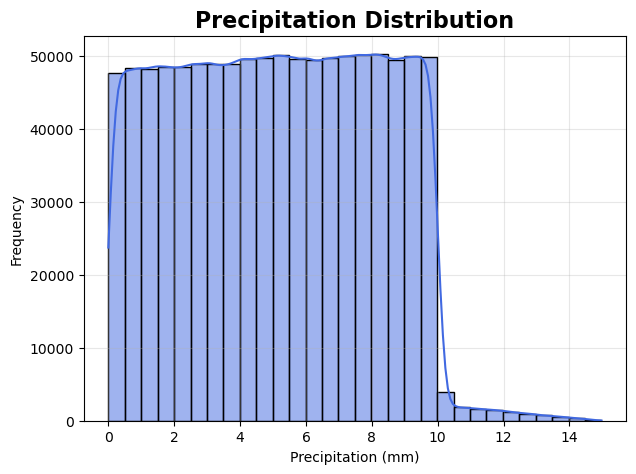

In [7]:
plt.figure(figsize=(7,5))

sns.histplot(
    df['Precipitation_mm'],
    bins=30,
    kde=True,
    color='royalblue'
)

plt.title(
    "Precipitation Distribution",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Precipitation (mm)")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()




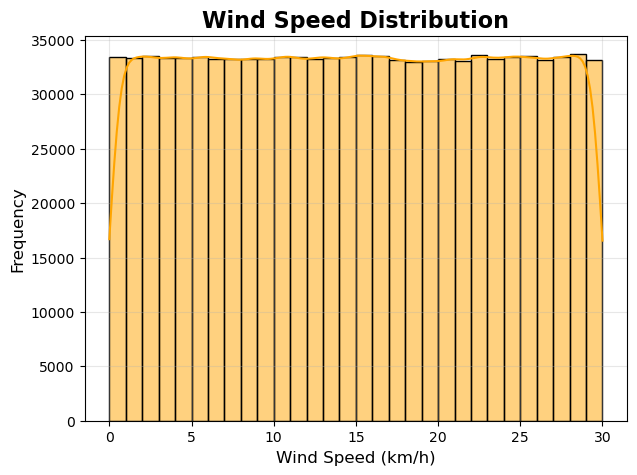

In [8]:
plt.figure(figsize=(7,5))

sns.histplot(
    df['Wind_Speed_kmh'],
    bins=30,
    kde=True,
    color='orange'
)

plt.title(
    "Wind Speed Distribution",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Wind Speed (km/h)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.grid(alpha=0.3)

plt.show()




STEP 4: Create Target Variable

Since the dataset does not contain predefined labels like:

sunny
rainy

we create our own rule-based target class.


IF precipitation > 2 mm

THEN Rainy

ELSE Sunny

In [9]:
df['Weather_Type'] = np.where(
    df['Precipitation_mm'] > 2,
    'Rainy',
    'Sunny'
)

print(df[['Precipitation_mm', 'Weather_Type']].head())



   Precipitation_mm Weather_Type
0          4.020119        Rainy
1          9.111623        Rainy
2          4.607511        Rainy
3          3.183720        Rainy
4          9.598282        Rainy


Visualize Target Classes

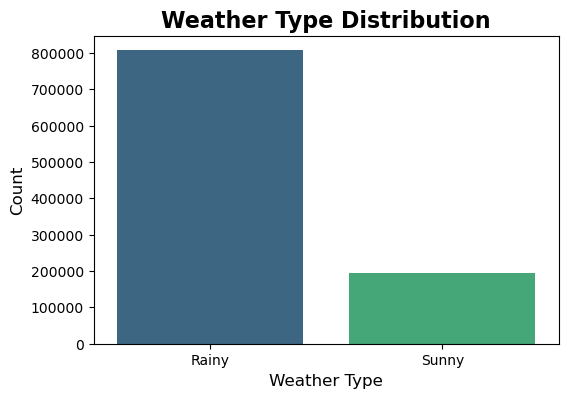

In [10]:
plt.figure(figsize=(6,4))

sns.countplot(
    x=df['Weather_Type'],
    palette='viridis'
)

plt.title(
    "Weather Type Distribution",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Weather Type", fontsize=12)
plt.ylabel("Count", fontsize=12)

plt.show()




STEP 5: Select Features and Target

In [11]:
X = df[
    [
        'Temperature_C',
        'Humidity_pct',
        'Precipitation_mm',
        'Wind_Speed_kmh'
    ]
]

y = df['Weather_Type']



STEP 6: Encode Labels

Machine learning algorithms require numerical labels.

In [12]:
encoder = LabelEncoder()

y = encoder.fit_transform(y)

print(y[:10])



[0 0 0 0 0 0 1 0 0 0]


STEP 7: Train Rule-Based Classifier

Algorithm Used:

Decision Tree Classifier

In [13]:
model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=4,
    random_state=42
)

model.fit(X, y)



,criterion,'entropy'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


Explanation

| Parameter           | Meaning                    |
| ------------------- | -------------------------- |
| criterion='entropy' | Uses entropy for splitting |
| max_depth=4         | Controls tree size         |
| random_state=42     | Reproducible results       |




STEP 8: Predictions

In [14]:
y_pred = model.predict(X)


STEP 9: Accuracy Calculation
Accuracy Formula

Accuracy=
Total Predictions / Correct Predictions



In [15]:
accuracy = accuracy_score(y, y_pred)

print("Accuracy:", accuracy)



Accuracy: 1.0


STEP 10: Confusion Matrix

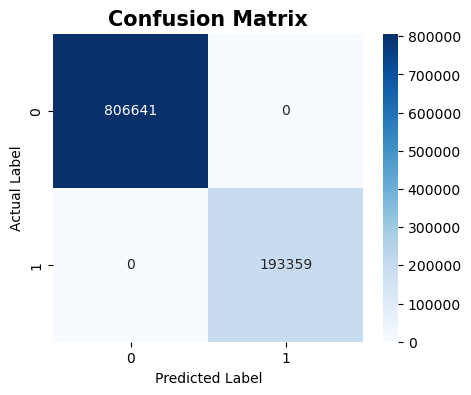

In [16]:
cm = confusion_matrix(y, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.title(
    "Confusion Matrix",
    fontsize=15,
    fontweight='bold'
)

plt.show()




STEP 12: Visualize Decision Tree Rules

THIS IS THE MOST IMPORTANT STEP OF RULE-BASED LEARNING.

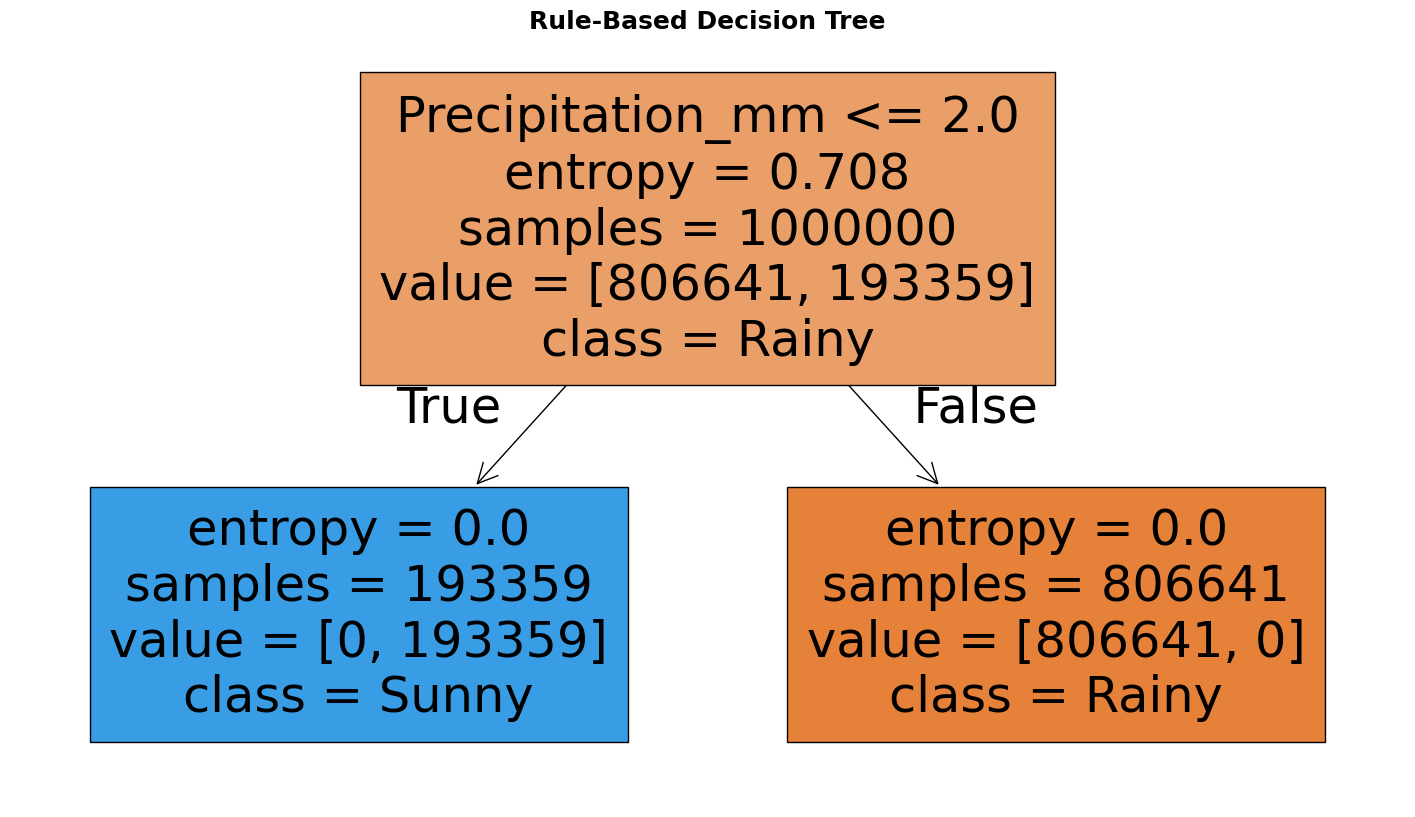

In [17]:
plt.figure(figsize=(18,10))

tree.plot_tree(
    model,
    feature_names=X.columns,
    class_names=['Rainy', 'Sunny'],
    filled=True
)

plt.title(
    "Rule-Based Decision Tree",
    fontsize=18,
    fontweight='bold'
)

plt.show()




STEP 13: Extract IF–THEN Rules

In [18]:
rules = tree.export_text(
    model,
    feature_names=list(X.columns)
)

print(rules)



|--- Precipitation_mm <= 2.00
|   |--- class: 1
|--- Precipitation_mm >  2.00
|   |--- class: 0



Final Result

The Decision Tree classifier successfully generated IF–THEN rule-based classification rules from real-world weather data. 

Advantages

Easy interpretation

Human-readable rules

Transparent predictions

Useful for expert systems

Limitations

Can overfit large datasets

Complex trees become difficult to interpret

Sensitive to noisy data

Viva Questions
Q1. What is rule-based classification?

Rule-based classification predicts classes using IF–THEN logical rules.

Q2. Why is Decision Tree called a rule-based algorithm?

Because each path from root to leaf forms a decision rule.

Q3. What is entropy?

Entropy measures impurity or disorder in data.

Q4. Why was Label Encoding used?

Machine learning models require numerical labels.

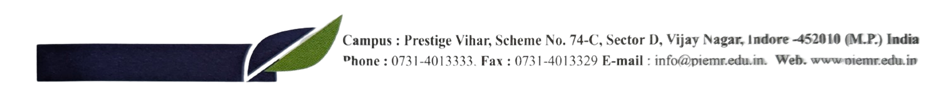